In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

data = pd.read_parquet('data/prepared_data_good.parquet')
print(data.shape)
print(f"Fraud procentas: {data['Is Fraud?'].mean()*100:.3f}%")

(2720821, 36)
Fraud procentas: 0.674%


In [4]:
data['date'] = pd.to_datetime(data[['Year', 'Month', 'Day']])
data_sorted = data.sort_values('date').reset_index(drop=True)

split_i = int(len(data_sorted) * 0.85)
train_val_data = data_sorted.iloc[:split_i].copy()
test_data = data_sorted.iloc[split_i:].copy()

train_val_data.drop(columns=['date', 'Year'], inplace=True)
test_data.drop(columns=['date', 'Year'], inplace=True)

print(f"Train: {len(train_val_data)} eil | fraud: {train_val_data['Is Fraud?'].mean()*100:.3f}%")
print(f"Test:  {len(test_data)} eil | fraud: {test_data['Is Fraud?'].mean()*100:.3f}%")

Train: 2312697 eil | fraud: 0.788%
Test:  408124 eil | fraud: 0.031%


In [5]:
X_tv = train_val_data.drop(columns=['Is Fraud?'])
y_tv = train_val_data['Is Fraud?']

X_test = test_data.drop(columns=['Is Fraud?'])
y_test = test_data['Is Fraud?']

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=0.20,
    random_state=67,
    stratify=y_tv
)

print(f"Train: {len(X_train)} eil | fraud: {y_train.mean()*100:.3f}%")
print(f"Val: {len(X_val)} eil | fraud: {y_val.mean()*100:.3f}%")
print(f"Test: {len(X_test)} eil | fraud: {y_test.mean()*100:.3f}%")

Train: 1850157 eil | fraud: 0.788%
Val: 462540 eil | fraud: 0.788%
Test: 408124 eil | fraud: 0.031%


In [6]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt

def get_predictions(model, X, threshold=0.5):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    return y_proba, y_pred


def print_metrics(name, label, threshold, y, y_pred, y_proba):
    print("*************************************************************************")
    print(f"{name} | {label} | threshold={threshold:.3f}")
    print("*************************************************************************")
    print(classification_report(y, y_pred, target_names=['Ne-fraud', 'Fraud']))
    print(f"Precision: {precision_score(y, y_pred):.4f}")
    print(f"Recall: {recall_score(y, y_pred):.4f}")
    print(f"F1: {f1_score(y, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y, y_proba):.4f}")
    print(f"PR-AUC: {average_precision_score(y, y_proba):.4f}")
    print()
    print(f"Confusion matrix: {confusion_matrix(y, y_pred)}")


def plot_pr_curve(ax, y, y_pred, y_proba, threshold):
    prec, rec, _ = precision_recall_curve(y, y_proba)
    pr_auc = average_precision_score(y, y_proba)
    ax.plot(rec, prec, label=f'PR-AUC = {pr_auc:.4f}')
    ax.scatter(recall_score(y, y_pred), precision_score(y, y_pred),
               color='red', zorder=5, label=f'threshold={threshold:.3f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall')
    ax.legend()
    ax.grid(True)


def plot_roc_curve(ax, y, y_proba):
    fpr, tpr, _ = roc_curve(y, y_proba)
    roc_auc = roc_auc_score(y, y_proba)
    ax.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title('ROC Curve')
    ax.legend()
    ax.grid(True)


def plot_curves(name, label, y, y_pred, y_proba, threshold):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_pr_curve(axes[0], y, y_pred, y_proba, threshold)
    plot_roc_curve(axes[1], y, y_proba)
    plt.suptitle(f'{name} | {label}')
    plt.tight_layout()
    plt.show()


def full_evaluate(name, model, X, y, threshold = 0.5, label=''):
    y_proba, y_pred = get_predictions(model, X, threshold)
    print_metrics(name, label, threshold, y, y_pred, y_proba)
    plot_curves(name, label, y, y_pred, y_proba, threshold)
    results = {
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'f1': f1_score(y, y_pred),
        'roc_auc': roc_auc_score(y, y_proba),
        'pr_auc': average_precision_score(y, y_proba),
    }
    return results

def cv_score(model, X, y, cv=5, label=''):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=67)
    scores = cross_validate(
        model, X, y,
        cv=skf,
        scoring=['roc_auc', 'average_precision'],
        n_jobs=-1
    )
    print()
    print(f"CV-{cv} | {label}]")
    print(f"ROC-AUC: {scores['test_roc_auc'].mean():.4f}")
    print(f"std ROC-AUC: {scores['test_roc_auc'].std():.4f}")
    print(f"PR-AUC: {scores['test_average_precision'].mean():.4f}")
    print(f"std PR-AUC: {scores['test_average_precision'].std():.4f}")
    return scores

def balance_data(X, y, fraud_target_ratio):
    ratio = fraud_target_ratio / (1 - fraud_target_ratio)
    target_for_under = ratio / 2

    n_fraud = (y == 1).sum()
    n_majority_target = int(n_fraud / target_for_under)
    under_ratio = n_majority_target / (y == 0).sum()
    under_ratio = min(under_ratio, 1.0)

    print(f"=== Prieš balansavimą ===")
    print(f"  Fraud: {n_fraud}, Non-fraud: {(y==0).sum()}")
    print(f"  Fraud %: {y.mean()*100:.1f}%")
    print(f"  under_ratio: {under_ratio:.4f}, target_for_under: {target_for_under:.4f}, ratio: {ratio:.4f}")

    under = RandomUnderSampler(sampling_strategy={0: n_majority_target, 1: n_fraud}, random_state=67)
    X_u, y_u = under.fit_resample(X, y)

    print(f"\n=== Po undersampling ===")
    print(f"  Fraud: {(y_u==1).sum()}, Non-fraud: {(y_u==0).sum()}")
    print(f"  Fraud %: {y_u.mean()*100:.1f}%")

    over = SMOTE(sampling_strategy=ratio, random_state=67)
    X_bal, y_bal = over.fit_resample(X_u, y_u)

    print(f"\n=== Po SMOTE ===")
    print(f"  Fraud: {(y_bal==1).sum()}, Non-fraud: {(y_bal==0).sum()}")
    print(f"  Fraud %: {y_bal.mean()*100:.1f}%")

    return X_bal, y_bal



In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

## eks 1: nebalansuota

scale_pos_weight = 125.9

CV-5 | Nebalansuota]
ROC-AUC: 0.9947
std ROC-AUC: 0.0005
PR-AUC: 0.8977
std PR-AUC: 0.0066
[0]	validation_0-aucpr:0.10810
[50]	validation_0-aucpr:0.79761
[100]	validation_0-aucpr:0.82561
[150]	validation_0-aucpr:0.85365
[200]	validation_0-aucpr:0.87477
[250]	validation_0-aucpr:0.89165
[299]	validation_0-aucpr:0.89906
*************************************************************************
XGB – Nebalansuota | Validacija | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      0.98      0.99    458896
       Fraud       0.28      0.95      0.44      3644

    accuracy                           0.98    462540
   macro avg       0.64      0.96      0.71    462540
weighted avg       0.99      0.98      0.99    462540

Precision: 0.2842
Recall: 0.9476
F1: 0.4373
ROC-AUC: 0.9951
PR-AUC: 0.8991

Confusion matrix: [[450200   8696]
 [   191   3453]]


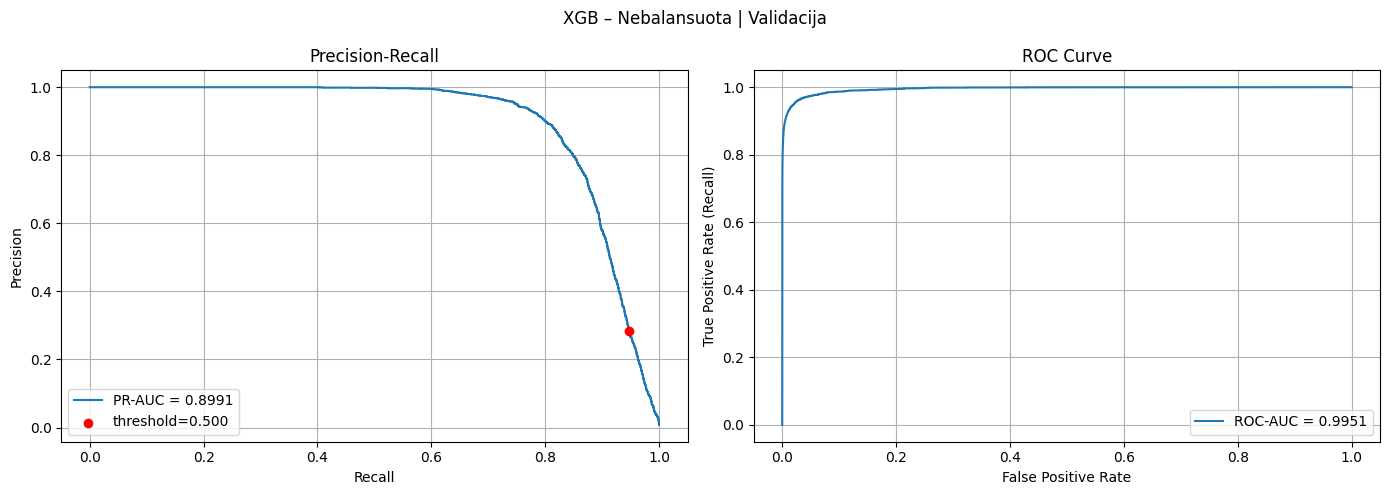

*************************************************************************
XGB – Nebalansuota | Testas | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      0.98      0.99    407996
       Fraud       0.02      0.90      0.03       128

    accuracy                           0.98    408124
   macro avg       0.51      0.94      0.51    408124
weighted avg       1.00      0.98      0.99    408124

Precision: 0.0172
Recall: 0.8984
F1: 0.0337
ROC-AUC: 0.9928
PR-AUC: 0.6951

Confusion matrix: [[401415   6581]
 [    13    115]]


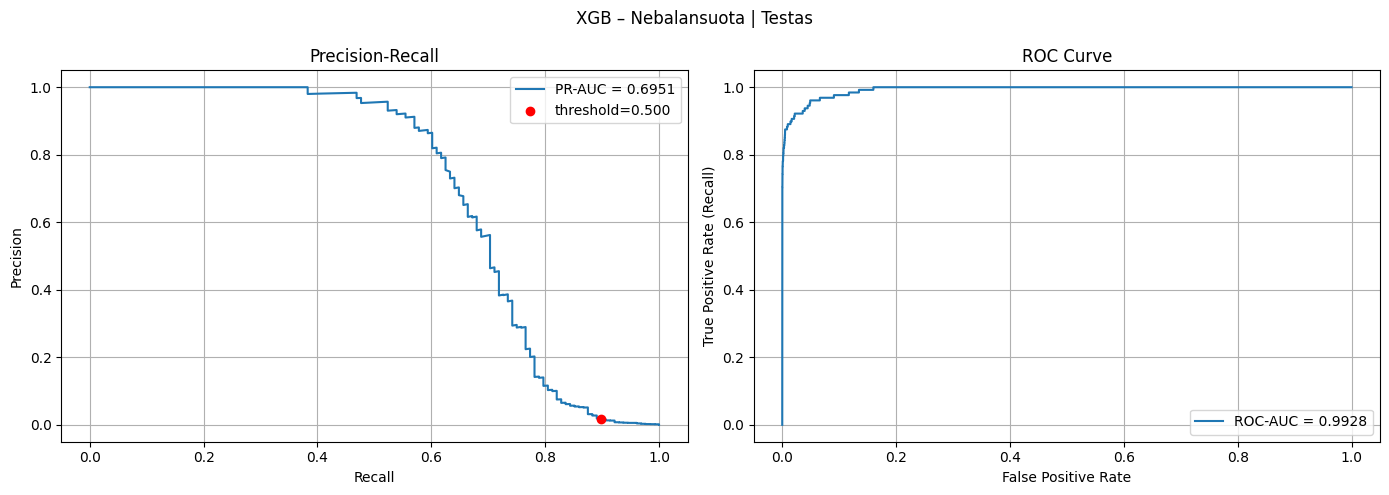

In [8]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

xgb_no_bal = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=67,
    use_label_encoder=False,
    n_jobs=-1
)

cv_score(xgb_no_bal, X_train_scaled, y_train, cv=5, label='Nebalansuota')

xgb_no_bal.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=50
)

results_no_bal_val  = full_evaluate("XGB – Nebalansuota", xgb_no_bal, X_val_scaled,  y_val,  label='Validacija')
results_no_bal_test = full_evaluate("XGB – Nebalansuota", xgb_no_bal, X_test_scaled, y_test, label='Testas')

In [ ]:
import numpy as np
import pandas as pd

y_proba_val, _ = get_predictions(xgb_no_bal, X_val_scaled)

results_no_bal = []

thresholds = np.arange(0.001, 0.55, 0.05)

for t in thresholds:
    y_pred = (y_proba_val >= t).astype(int)
    results_no_bal.append({
        'threshold': round(t, 3),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall': recall_score(y_val, y_pred, zero_division=0),
        'f1': f1_score(y_val, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_val, y_proba_val),
    })
a
df = pd.DataFrame(results_no_bal)
print(df.to_string(index=False))

print(df.nlargest(3, 'f1').to_string(index=False))

 threshold  precision   recall       f1   pr_auc
     0.001   0.009173 1.000000 0.018179 0.899062
     0.051   0.033397 0.996707 0.064629 0.899062
     0.101   0.048683 0.992316 0.092812 0.899062
     0.151   0.066259 0.988200 0.124192 0.899062
     0.201   0.087075 0.985181 0.160007 0.899062
     0.251   0.110436 0.978046 0.198463 0.899062
     0.301   0.137685 0.973655 0.241254 0.899062
     0.351   0.167799 0.968990 0.286061 0.899062
     0.401   0.201389 0.962953 0.333112 0.899062
     0.451   0.239472 0.956641 0.383056 0.899062
     0.501   0.285454 0.947311 0.438711 0.899062
 threshold  precision   recall       f1   pr_auc
     0.501   0.285454 0.947311 0.438711 0.899062
     0.451   0.239472 0.956641 0.383056 0.899062
     0.401   0.201389 0.962953 0.333112 0.899062


## eks 2: balansuota iki 10

=== Prieš balansavimą ===
  Fraud: 14577, Non-fraud: 1835580
  Fraud %: 0.8%
  under_ratio: 0.1429, target_for_under: 0.0556, ratio: 0.1111

=== Po undersampling ===
  Fraud: 14577, Non-fraud: 262386
  Fraud %: 5.3%

=== Po SMOTE ===
  Fraud: 29154, Non-fraud: 262386
  Fraud %: 10.0%

CV-5 | 10% fraud]
ROC-AUC: 0.9965
std ROC-AUC: 0.0003
PR-AUC: 0.9833
std PR-AUC: 0.0007
[0]	validation_0-aucpr:0.14706
[50]	validation_0-aucpr:0.83471
[100]	validation_0-aucpr:0.86476
[150]	validation_0-aucpr:0.87998
[200]	validation_0-aucpr:0.89221
[250]	validation_0-aucpr:0.90074
[299]	validation_0-aucpr:0.90705
*************************************************************************
XGB – 10% fraud | Validacija | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      1.00      1.00    458896
       Fraud       0.78      0.87      0.82      3644

    accuracy                           

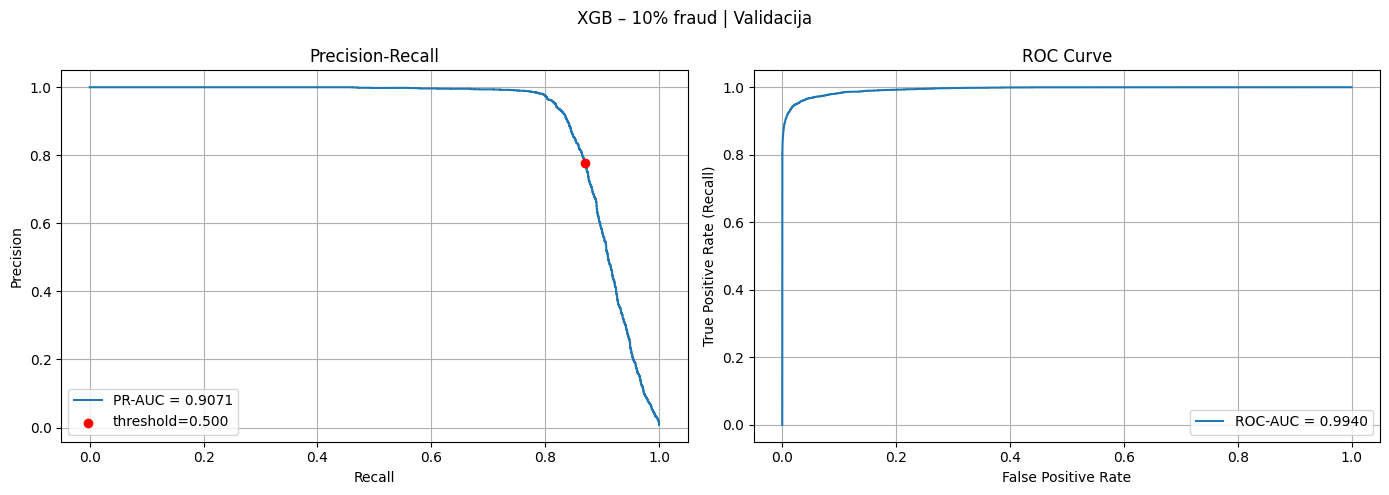

*************************************************************************
XGB – 10% fraud | Testas | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      1.00      1.00    407996
       Fraud       0.13      0.79      0.22       128

    accuracy                           1.00    408124
   macro avg       0.56      0.89      0.61    408124
weighted avg       1.00      1.00      1.00    408124

Precision: 0.1270
Recall: 0.7891
F1: 0.2189
ROC-AUC: 0.9914
PR-AUC: 0.7569

Confusion matrix: [[407302    694]
 [    27    101]]


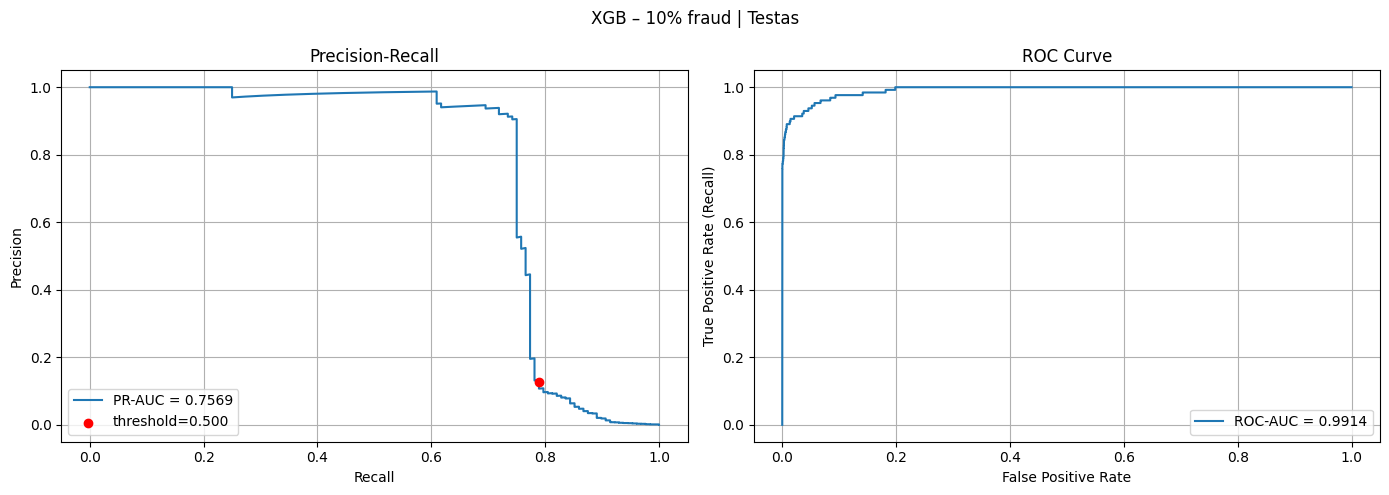

In [10]:
X_train_10, y_train_10 = balance_data(X_train_scaled, y_train, fraud_target_ratio=0.10)

xgb_10 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=67,
    use_label_encoder=False,
    n_jobs=-1
)

cv_score(xgb_10, X_train_10, y_train_10, cv=5, label='10% fraud')

xgb_10.fit(
    X_train_10, y_train_10,
    eval_set=[(X_val_scaled, y_val)],
    verbose=50
)

results_10_val  = full_evaluate("XGB – 10% fraud", xgb_10, X_val_scaled,  y_val,  label='Validacija')
results_10_test = full_evaluate("XGB – 10% fraud", xgb_10, X_test_scaled, y_test, label='Testas')

In [11]:
import numpy as np
import pandas as pd

y_proba_val, _ = get_predictions(xgb_10, X_val_scaled)

results_10 = []

thresholds = np.arange(0.001, 0.55, 0.05)

for t in thresholds:
    y_pred = (y_proba_val >= t).astype(int)
    results_10.append({
        'threshold': round(t, 3),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall': recall_score(y_val, y_pred, zero_division=0),
        'f1': f1_score(y_val, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_val, y_proba_val),
    })

df = pd.DataFrame(results_10)
print(df.to_string(index=False))

print(df.nlargest(3, 'f1').to_string(index=False))

 threshold  precision   recall       f1   pr_auc
     0.001   0.012956 1.000000 0.025581 0.907053
     0.051   0.129219 0.968716 0.228021 0.907053
     0.101   0.271174 0.945390 0.421458 0.907053
     0.151   0.416429 0.922338 0.573794 0.907053
     0.201   0.521527 0.907519 0.662394 0.907053
     0.251   0.590999 0.897366 0.712651 0.907053
     0.301   0.639299 0.891054 0.744469 0.907053
     0.351   0.678932 0.886114 0.768810 0.907053
     0.401   0.708140 0.880900 0.785129 0.907053
     0.451   0.742033 0.875412 0.803223 0.907053
     0.501   0.778870 0.869923 0.821882 0.907053
 threshold  precision   recall       f1   pr_auc
     0.501   0.778870 0.869923 0.821882 0.907053
     0.451   0.742033 0.875412 0.803223 0.907053
     0.401   0.708140 0.880900 0.785129 0.907053


## eks 3: nebalansuota

=== Prieš balansavimą ===
  Fraud: 14577, Non-fraud: 1835580
  Fraud %: 0.8%
  under_ratio: 0.0322, target_for_under: 0.2463, ratio: 0.4925

=== Po undersampling ===
  Fraud: 14577, Non-fraud: 59191
  Fraud %: 19.8%

=== Po SMOTE ===
  Fraud: 29153, Non-fraud: 59191
  Fraud %: 33.0%

CV-5 | 33% fraud]
ROC-AUC: 0.9963
std ROC-AUC: 0.0001
PR-AUC: 0.9938
std PR-AUC: 0.0002
[0]	validation_0-aucpr:0.09709
[50]	validation_0-aucpr:0.79017
[100]	validation_0-aucpr:0.82901
[150]	validation_0-aucpr:0.85251
[200]	validation_0-aucpr:0.87041
[250]	validation_0-aucpr:0.88427
[299]	validation_0-aucpr:0.89127
*************************************************************************
XGB – 33% fraud | Validacija | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      0.99      1.00    458896
       Fraud       0.49      0.91      0.63      3644

    accuracy                           0

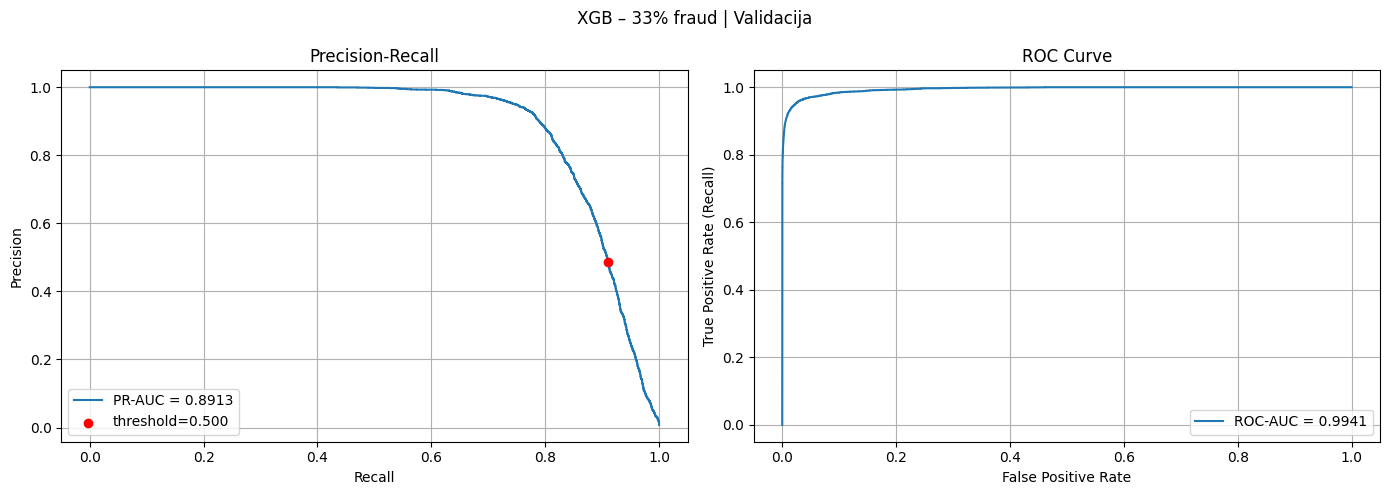

*************************************************************************
XGB – 33% fraud | Testas | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      0.99      1.00    407996
       Fraud       0.04      0.86      0.07       128

    accuracy                           0.99    408124
   macro avg       0.52      0.93      0.53    408124
weighted avg       1.00      0.99      1.00    408124

Precision: 0.0377
Recall: 0.8594
F1: 0.0723
ROC-AUC: 0.9919
PR-AUC: 0.6752

Confusion matrix: [[405191   2805]
 [    18    110]]


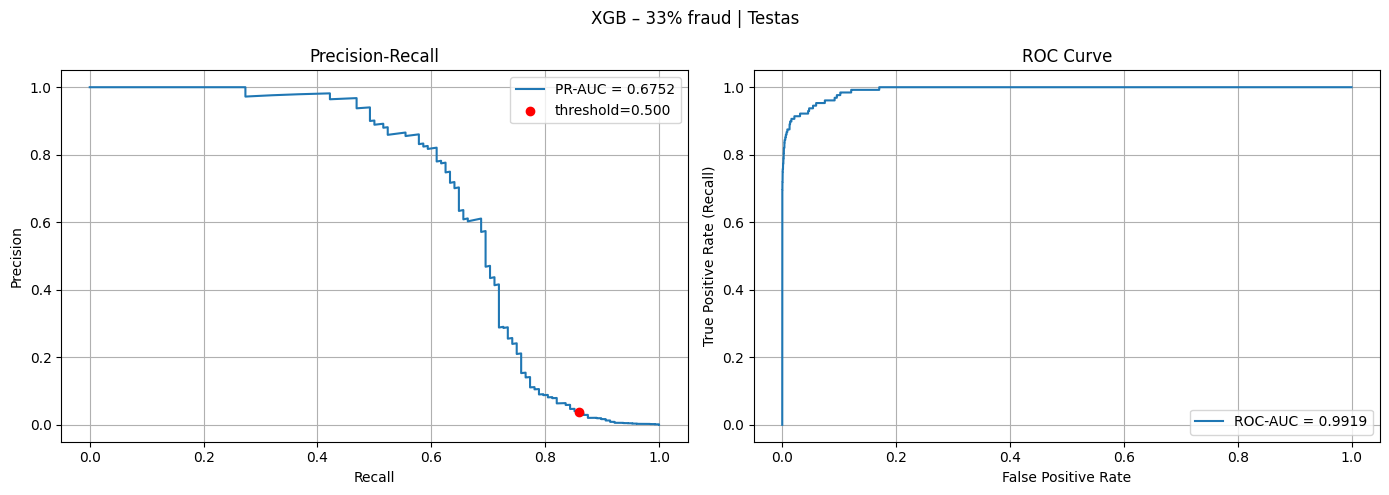

In [12]:
X_train_33, y_train_33 = balance_data(X_train_scaled, y_train, fraud_target_ratio=0.33)

xgb_33 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=67,
    use_label_encoder=False,
    n_jobs=-1
)

cv_score(xgb_33, X_train_33, y_train_33, cv=5, label='33% fraud')

xgb_33.fit(
    X_train_33, y_train_33,
    eval_set=[(X_val_scaled, y_val)],
    verbose=50
)

results_33_val  = full_evaluate("XGB – 33% fraud", xgb_33, X_val_scaled,  y_val,  label='Validacija')
results_33_test = full_evaluate("XGB – 33% fraud", xgb_33, X_test_scaled, y_test, label='Testas')

In [13]:
import numpy as np
import pandas as pd

y_proba_val, _ = get_predictions(xgb_33, X_val_scaled)

results_33 = []

thresholds = np.arange(0.001, 0.55, 0.05)

for t in thresholds:
    y_pred = (y_proba_val >= t).astype(int)
    results_33.append({
        'threshold': round(t, 3),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall': recall_score(y_val, y_pred, zero_division=0),
        'f1': f1_score(y_val, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_val, y_proba_val),
    })

df = pd.DataFrame(results_33)
print(df.to_string(index=False))

print(df.nlargest(3, 'f1').to_string(index=False))

 threshold  precision   recall       f1   pr_auc
     0.001   0.008455 1.000000 0.016768 0.891275
     0.051   0.042796 0.992042 0.082052 0.891275
     0.101   0.074316 0.983809 0.138193 0.891275
     0.151   0.114860 0.972558 0.205455 0.891275
     0.201   0.158207 0.966520 0.271906 0.891275
     0.251   0.204829 0.959111 0.337567 0.891275
     0.301   0.256420 0.948134 0.403669 0.891275
     0.351   0.314186 0.939627 0.470912 0.891275
     0.401   0.372075 0.929473 0.531419 0.891275
     0.451   0.431456 0.920692 0.587566 0.891275
     0.501   0.487869 0.910538 0.635328 0.891275
 threshold  precision   recall       f1   pr_auc
     0.501   0.487869 0.910538 0.635328 0.891275
     0.451   0.431456 0.920692 0.587566 0.891275
     0.401   0.372075 0.929473 0.531419 0.891275


---
## 6. XGBoost parametrai


| Parametras | Default | Ką daro |
|---|---|---|
| `n_estimators` | 100 | Kiek medžių |
| `max_depth` | 6 | Medžio gylis |
| `learning_rate` | 0.3 | Žingsnis |
| `subsample` | 1.0 | Kiek % eilučių naudojama kiekvienam medžiui |
| `colsample_bytree` | 1.0 | Kiek % požymių naudojama kiekvienam medžiui |
| `min_child_weight` | 1 | Min. svorių suma lape |
| `gamma` | 0 | Min. loss sumažėjimas splitui |
| `reg_alpha` | 0 | L1 regularizacija |
| `reg_lambda` | 1 | L2 regularizacija |

In [14]:
X_train_best = X_train_10
y_train_best = y_train_10

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.7, 0.8, 1.0],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

base_xgb = xgb.XGBClassifier(
    n_estimators=200,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=67,
    use_label_encoder=False,
    n_jobs=-1
)

grid = GridSearchCV(
    base_xgb,
    param_grid,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_best, y_train_best)

print("Geriausi parametrai:", grid.best_params_)
print(f"Geriausia CV PR-AUC: {grid.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Geriausi parametrai: {'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.7}
Geriausia CV PR-AUC: 0.9893


*************************************************************************
XGB – GridSearch | Validacija | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      1.00      1.00    458896
       Fraud       0.87      0.88      0.87      3644

    accuracy                           1.00    462540
   macro avg       0.93      0.94      0.94    462540
weighted avg       1.00      1.00      1.00    462540

Precision: 0.8653
Recall: 0.8817
F1: 0.8735
ROC-AUC: 0.9959
PR-AUC: 0.9303

Confusion matrix: [[458396    500]
 [   431   3213]]


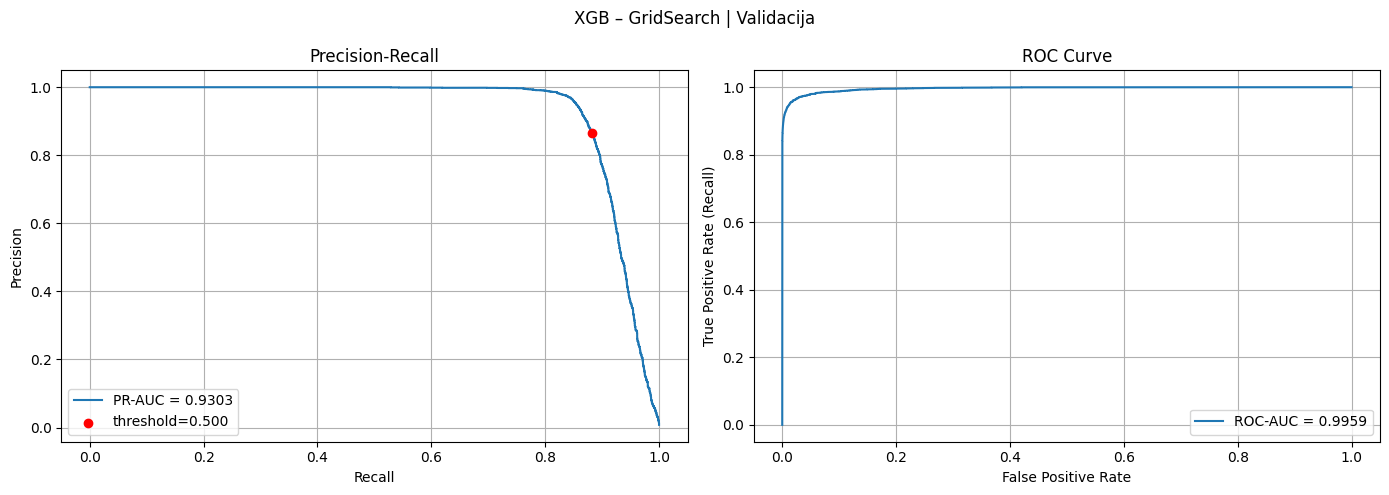

*************************************************************************
XGB – GridSearch | Testas | threshold=0.500
*************************************************************************
              precision    recall  f1-score   support

    Ne-fraud       1.00      1.00      1.00    407996
       Fraud       0.21      0.82      0.33       128

    accuracy                           1.00    408124
   macro avg       0.60      0.91      0.67    408124
weighted avg       1.00      1.00      1.00    408124

Precision: 0.2071
Recall: 0.8203
F1: 0.3307
ROC-AUC: 0.9930
PR-AUC: 0.7816

Confusion matrix: [[407594    402]
 [    23    105]]


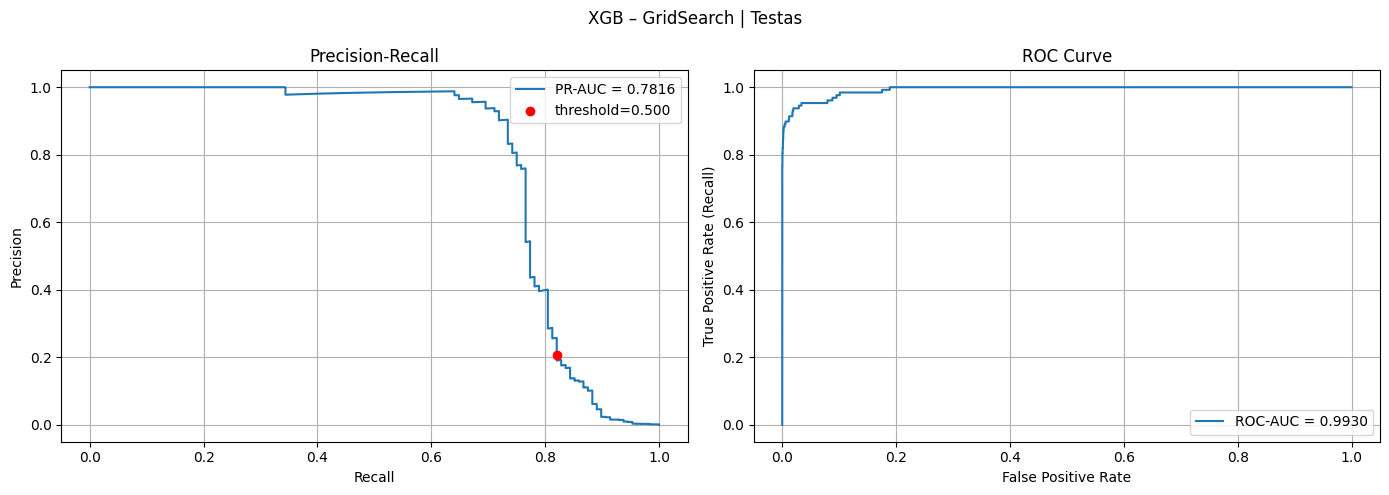

In [15]:
best_xgb = grid.best_estimator_

results_grid_val  = full_evaluate("XGB – GridSearch", best_xgb, X_val_scaled,  y_val,  label='Validacija')
results_grid_test = full_evaluate("XGB – GridSearch", best_xgb, X_test_scaled, y_test, label='Testas')

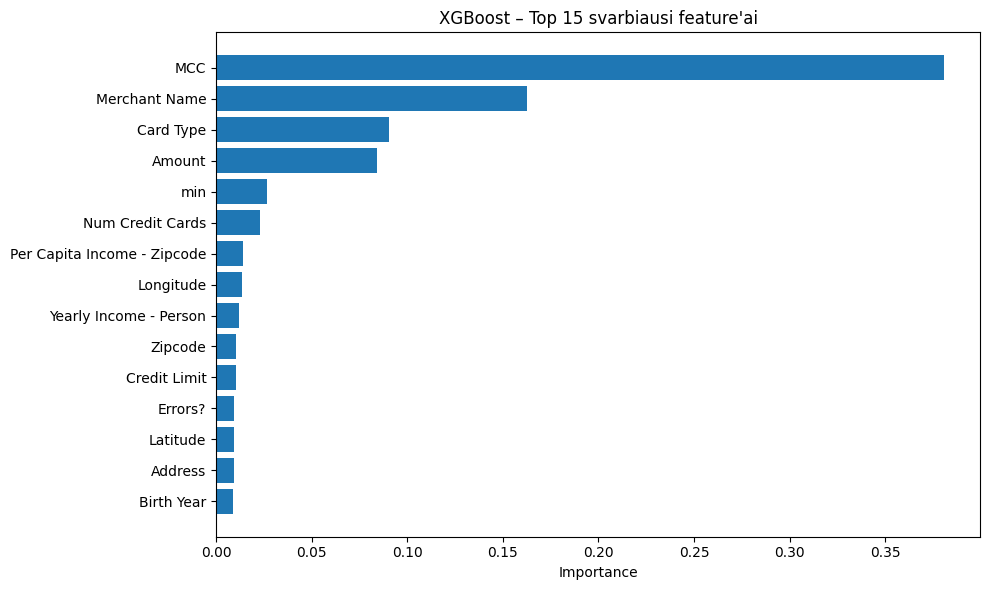

                    feature  importance
                        MCC    0.380536
              Merchant Name    0.162602
                  Card Type    0.090582
                     Amount    0.084112
                        min    0.026852
           Num Credit Cards    0.023191
Per Capita Income - Zipcode    0.014022
                  Longitude    0.013413
     Yearly Income - Person    0.011962
                    Zipcode    0.010507
               Credit Limit    0.010215
                    Errors?    0.009558
                   Latitude    0.009341
                    Address    0.009225
                 Birth Year    0.008933
                 FICO Score    0.008926
                 Total Debt    0.008394
                      State    0.008374
        Acct Open Date year    0.008370
                       City    0.008078
             Retirement Age    0.008044
      Year PIN last Changed    0.007880
                Card Number    0.007716
                      Month    0.007699


In [16]:
import matplotlib.pyplot as plt

feature_names = X_train.columns.tolist()
importances = best_xgb.feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['feature'][:15][::-1], fi_df['importance'][:15][::-1])
plt.title('XGBoost – Top 15 svarbiausi feature\'ai')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))

In [17]:
import joblib
import os
os.makedirs('models', exist_ok=True)

joblib.dump(best_xgb, 'models/xgb_best.pkl')
joblib.dump(scaler, 'models/scaler.pkl')


['models/scaler.pkl']

In [18]:
import shap

sample_idx = np.random.default_rng(67).choice(len(X_test_scaled), size=2000, replace=False)
X_shap = X_test_scaled[sample_idx]

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_shap)

feature_names = X_train.columns.tolist()

shap.summary_plot(shap_values, X_shap, feature_names=feature_names, max_display=20)

shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type='bar', max_display=20)


ModuleNotFoundError: No module named 'shap'